# CS514 Parameter Refinement Walkthrough

This notebook documents several backbone/community-detection settings and the main validated parameter set for the CS514 BGG co-ownership network.

Main final setting:

- ownership layer
- Newman user-normalized game-game projection
- disparity backbone `alpha = 0.025`
- Louvain resolution `gamma = 1.75`

The notebook focuses on outputs that matter for explanation: edge counts, community counts, largest community size, stability/NMI, modularity, null-model results, and final interpretation.

## Parameter Meaning

### Alpha: disparity-backbone strictness

`alpha` controls how strict the disparity backbone filter is, lower alpha indicates stricter pruning. It affects the graph before community detection.

In this project:

- `alpha = 0.001` produced a sparse, clean, macro-level graph.
- `alpha = 0.025` produced a richer graph that could support interpretable midline communities.
- `alpha = 0.05` was considered too dense/noisy for the final headline graph.

### Gamma: Louvain community resolution

`gamma` controls the resolution of community detection. Lower gamma causes fewer but larger communities.

I've searched for the highest useful gamma that remained stable and statistically meaningful.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DIAG = PROJECT_ROOT / "data" / "processed" / "cs514_network_analysis" / "diagnostics"
FIG_DIR = PROJECT_ROOT / "data" / "processed" / "cs514_network_analysis" / "figures" / "parameter_refinement"
FIG_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "initial_sweep": DIAG / "parameter_sweep.csv",
    "confirm_20": DIAG / "parameter_sweep_confirm_20seeds.csv",
    "midline_null_sweep": DIAG / "merged_ownership_newman_disparity_a0p025_midline_gamma_null_sweep.csv",
    "midline_null_replicates": DIAG / "merged_ownership_newman_disparity_a0p025_midline_gamma_null_replicates.csv",
}

for name, path in paths.items():
    print(f"{name:24s} {path.exists()}  {path}")

initial_sweep            True  C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\diagnostics\parameter_sweep.csv
confirm_20               True  C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\diagnostics\parameter_sweep_confirm_20seeds.csv
midline_null_sweep       True  C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\diagnostics\merged_ownership_newman_disparity_a0p025_midline_gamma_null_sweep.csv
midline_null_replicates  True  C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\diagnostics\merged_ownership_newman_disparity_a0p025_midline_gamma_null_replicates.csv


In [2]:
initial = pd.read_csv(paths["initial_sweep"])
confirm = pd.read_csv(paths["confirm_20"])
midline = pd.read_csv(paths["midline_null_sweep"])
replicates = pd.read_csv(paths["midline_null_replicates"])

print("initial sweep", initial.shape)
print("20-seed confirmation", confirm.shape)
print("midline null sweep", midline.shape)
print("null replicates", replicates.shape)

initial sweep (30, 30)
20-seed confirmation (6, 30)
midline null sweep (6, 46)
null replicates (120, 7)


## Stage 1: Broad Alpha/Gamma Sweep

This was the first scan over candidate backbone strictness (`alpha`) and Louvain resolution (`gamma`, stored as `resolution` in the sweep CSV). It used 10 seeds per setting and gave us a first sense of stability, graph size, and community granularity.

In [3]:
initial_table_cols = [
    "alpha",
    "resolution",
    "n_seeds",
    "edges",
    "density",
    "average_degree",
    "isolates",
    "n_communities",
    "largest_community_fraction",
    "median_pairwise_nmi",
    "representative_modularity",
    "stability_pass_nmi_0p70",
    "largest_community_le_75pct",
]

initial_table = initial[initial_table_cols].copy()
initial_table = initial_table.sort_values(["alpha", "resolution"])
initial_table["largest_community_pct"] = initial_table["largest_community_fraction"] * 100
initial_table = initial_table.drop(columns=["largest_community_fraction"])

display(initial_table.round({
    "density": 4,
    "average_degree": 1,
    "median_pairwise_nmi": 3,
    "representative_modularity": 3,
    "largest_community_pct": 1,
}))

,alpha,resolution,n_seeds,edges,density,average_degree,isolates,n_communities,median_pairwise_nmi,representative_modularity,stability_pass_nmi_0p70,largest_community_le_75pct,largest_community_pct
0,0.001,0.50,10,30530,0.0098,24.4,28,31,0.688,0.505,False,False,95.2
1,0.001,0.75,10,30530,0.0098,24.4,28,32,0.753,0.351,True,True,49.6
2,0.001,1.00,10,30530,0.0098,24.4,28,36,0.595,0.249,False,True,34.7
3,0.001,1.25,10,30530,0.0098,24.4,28,36,0.608,0.194,False,True,24.7
4,0.001,1.50,10,30530,0.0098,24.4,28,42,0.614,0.157,False,True,16.0
5,0.001,2.00,10,30530,0.0098,24.4,28,53,0.684,0.118,False,True,10.2
6,0.005,0.50,10,79907,0.0256,63.9,0,2,0.980,0.501,True,False,96.9
7,0.005,0.75,10,79907,0.0256,63.9,0,2,0.603,0.313,False,True,54.0
8,0.005,1.00,10,79907,0.0256,63.9,0,8,0.640,0.216,False,True,34.6
9,0.005,1.25,10,79907,0.0256,63.9,0,10,0.615,0.160,False,True,23.9


### Initial Sweep Heatmaps

The two most useful early diagnostics were:

- median pairwise NMI across seeds: are communities stable?
- number of communities: are communities too coarse or too fragmented?

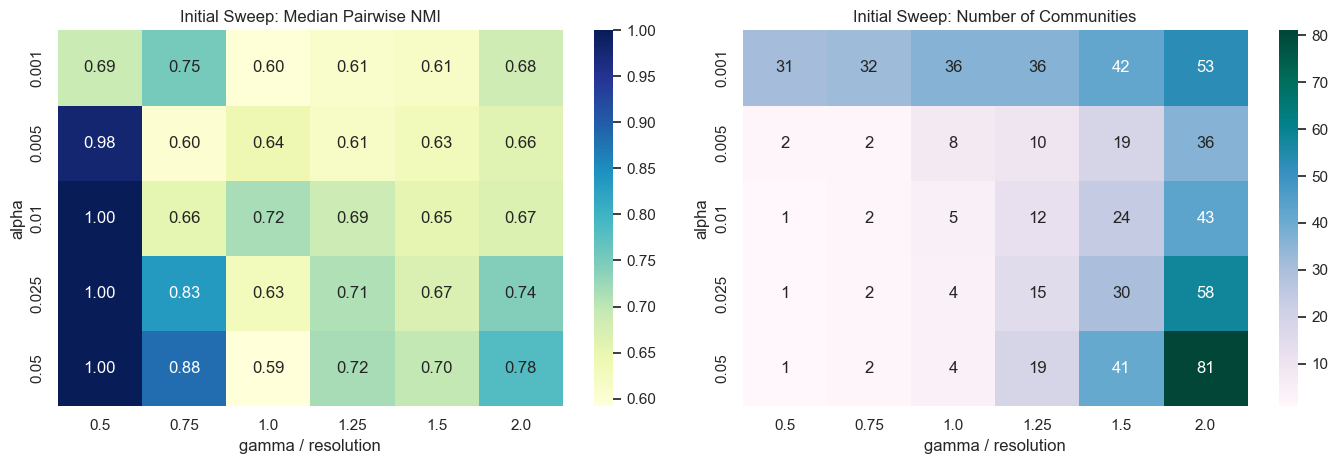

In [4]:
def pivot_metric(df, metric):
    return df.pivot_table(index="alpha", columns="resolution", values=metric, aggfunc="first").sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.heatmap(pivot_metric(initial, "median_pairwise_nmi"), annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Initial Sweep: Median Pairwise NMI")
axes[0].set_xlabel("gamma / resolution")
axes[0].set_ylabel("alpha")

sns.heatmap(pivot_metric(initial, "n_communities"), annot=True, fmt=".0f", cmap="PuBuGn", ax=axes[1])
axes[1].set_title("Initial Sweep: Number of Communities")
axes[1].set_xlabel("gamma / resolution")
axes[1].set_ylabel("alpha")

fig.tight_layout()
fig.savefig(FIG_DIR / "initial_alpha_gamma_sweep_heatmaps.png", dpi=200, bbox_inches="tight")
plt.show()

## Stage 2: 20-Seed Confirmation

The first sweep used 10 seeds. We then confirmed promising settings with 20 seeds to reduce the chance that stability was just a random-seed artifact.

In [5]:
confirm_cols = [
    "alpha",
    "resolution",
    "n_seeds",
    "edges",
    "average_degree",
    "isolates",
    "n_communities",
    "largest_community_fraction",
    "median_pairwise_nmi",
    "representative_modularity",
    "stability_pass_nmi_0p70",
    "largest_community_le_75pct",
]
confirm_table = confirm[confirm_cols].sort_values(["alpha", "resolution"]).copy()
confirm_table["largest_community_pct"] = confirm_table["largest_community_fraction"] * 100
confirm_table = confirm_table.drop(columns=["largest_community_fraction"])
confirm_table.round({"average_degree": 1, "median_pairwise_nmi": 3, "representative_modularity": 3, "largest_community_pct": 1})

,alpha,resolution,n_seeds,edges,average_degree,isolates,n_communities,median_pairwise_nmi,representative_modularity,stability_pass_nmi_0p70,largest_community_le_75pct,largest_community_pct
0,0.001,0.75,20,30530,24.4,28,32,0.765,0.351,True,True,49.6
1,0.001,1.25,20,30530,24.4,28,36,0.613,0.194,False,True,24.7
2,0.025,0.75,20,214379,171.5,0,2,0.823,0.284,True,True,56.2
3,0.025,1.25,20,214379,171.5,0,15,0.692,0.124,False,True,25.2
4,0.050,0.75,20,337995,270.4,0,2,0.817,0.275,True,True,56.2
5,0.050,1.25,20,337995,270.4,0,20,0.718,0.108,True,True,21.9


## Stage 3: Targeted Midline Gamma + Null-Model Sweep

After the initial sweep, `alpha = 0.025` looked promising because it produced a rich graph without isolates. We then ran a targeted gamma sweep on that backbone and added a degree-preserving null-model test.

Selection gates:

- stability gate: median pairwise NMI >= 0.70
- null-model gate: z-score > 2

We wanted the highest-resolution setting that passed both gates.

In [6]:
midline_cols = [
    "gamma",
    "nodes",
    "edges",
    "average_degree",
    "isolates",
    "n_communities",
    "largest_community_fraction",
    "median_community_size",
    "communities_ge_20_games",
    "communities_ge_50_games",
    "median_pairwise_nmi",
    "observed_modularity",
    "null_mean_modularity",
    "null_std_modularity",
    "z_score",
    "null_mean_n_communities",
    "passes_nmi_gate",
    "passes_null_gate",
    "validated_midline_candidate",
]
midline_table = midline[midline_cols].copy()
midline_table["largest_community_pct"] = midline_table["largest_community_fraction"] * 100
midline_table = midline_table.drop(columns=["largest_community_fraction"])
midline_table.round({
    "average_degree": 1,
    "median_pairwise_nmi": 3,
    "observed_modularity": 3,
    "null_mean_modularity": 3,
    "null_std_modularity": 6,
    "z_score": 2,
    "null_mean_n_communities": 1,
    "largest_community_pct": 1,
})

,gamma,nodes,edges,average_degree,isolates,n_communities,median_community_size,communities_ge_20_games,communities_ge_50_games,median_pairwise_nmi,observed_modularity,null_mean_modularity,null_std_modularity,z_score,null_mean_n_communities,passes_nmi_gate,passes_null_gate,validated_midline_candidate,largest_community_pct
0,0.75,2500,214379,171.5,0,2,1250.0,2,2,0.752,0.284,0.250,0.000000,inf,1.0,True,True,True,56.2
1,1.00,2500,214379,171.5,0,4,685.0,4,4,0.594,0.176,0.083,0.000546,170.51,20.3,False,True,False,32.9
2,1.25,2500,214379,171.5,0,15,20.0,8,6,0.680,0.124,0.075,0.000361,135.18,58.8,False,True,False,25.2
3,1.50,2500,214379,171.5,0,32,15.5,14,8,0.703,0.094,0.071,0.000339,69.22,87.8,True,True,True,16.6
4,1.75,2500,214379,171.5,0,43,12.0,15,10,0.758,0.077,0.068,0.000320,27.31,111.3,True,True,True,13.5
5,2.00,2500,214379,171.5,0,57,11.0,19,11,0.767,0.064,0.066,0.000317,-3.46,127.8,True,False,False,12.3


### Midline Sweep Visualization

This figure shows the trade-off: as gamma increases, communities become more granular. The final selected setting is `gamma = 1.75` because it is stable and passes the null-model test while remaining detailed enough to interpret.

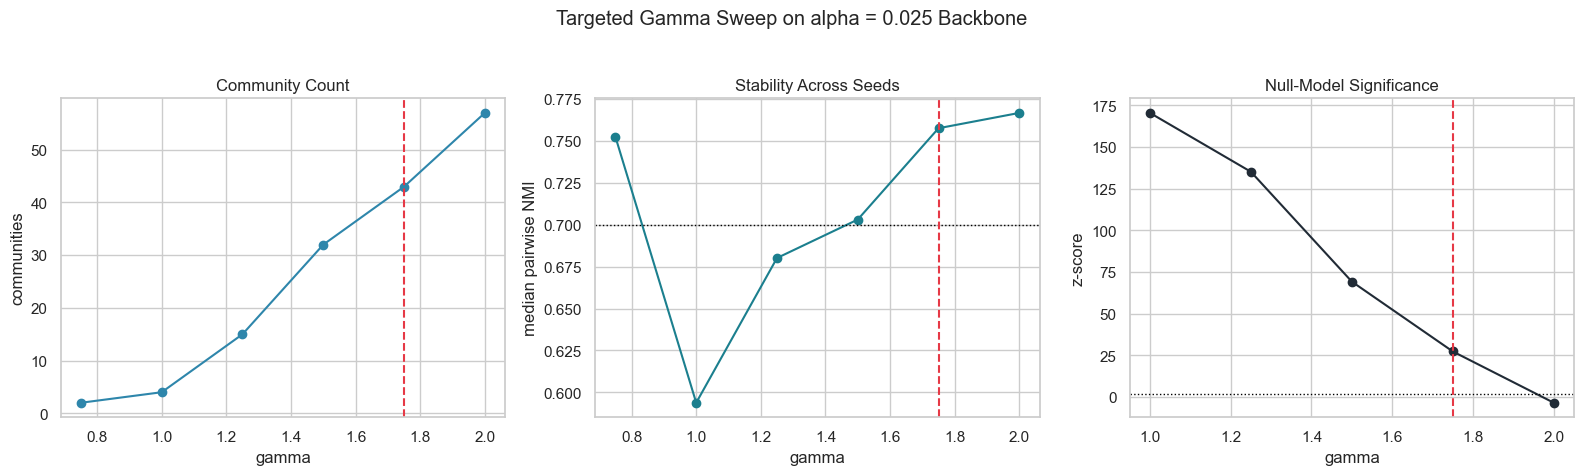

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

axes[0].plot(midline["gamma"], midline["n_communities"], marker="o", color="#2E86AB")
axes[0].axvline(1.75, color="#E63946", linestyle="--", linewidth=1.5)
axes[0].set_title("Community Count")
axes[0].set_xlabel("gamma")
axes[0].set_ylabel("communities")

axes[1].plot(midline["gamma"], midline["median_pairwise_nmi"], marker="o", color="#1B7F8E")
axes[1].axhline(0.70, color="black", linestyle=":", linewidth=1)
axes[1].axvline(1.75, color="#E63946", linestyle="--", linewidth=1.5)
axes[1].set_title("Stability Across Seeds")
axes[1].set_xlabel("gamma")
axes[1].set_ylabel("median pairwise NMI")

z_plot = midline["z_score"].replace([np.inf, -np.inf], np.nan)
axes[2].plot(midline["gamma"], z_plot, marker="o", color="#212B36")
axes[2].axhline(2, color="black", linestyle=":", linewidth=1)
axes[2].axvline(1.75, color="#E63946", linestyle="--", linewidth=1.5)
axes[2].set_title("Null-Model Significance")
axes[2].set_xlabel("gamma")
axes[2].set_ylabel("z-score")

fig.suptitle("Targeted Gamma Sweep on alpha = 0.025 Backbone", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "midline_gamma_sweep_validation.png", dpi=200, bbox_inches="tight")
plt.show()

## Stage 4: Observed vs Null Communities

A useful interpretation from the null-model sweep is that the real graph produced fewer, more coherent communities than the randomized null graphs at validated settings. The null graph tends to fragment because degree is preserved but meaningful cluster structure is disrupted.

In [8]:
null_comm_table = midline[[
    "gamma",
    "n_communities",
    "null_mean_n_communities",
    "observed_modularity",
    "null_mean_modularity",
    "z_score",
    "passes_nmi_gate",
    "passes_null_gate",
]].copy()
null_comm_table.round({
    "null_mean_n_communities": 1,
    "observed_modularity": 3,
    "null_mean_modularity": 3,
    "z_score": 2,
})

,gamma,n_communities,null_mean_n_communities,observed_modularity,null_mean_modularity,z_score,passes_nmi_gate,passes_null_gate
0,0.75,2,1.0,0.284,0.250,inf,True,True
1,1.00,4,20.3,0.176,0.083,170.51,False,True
2,1.25,15,58.8,0.124,0.075,135.18,False,True
3,1.50,32,87.8,0.094,0.071,69.22,True,True
4,1.75,43,111.3,0.077,0.068,27.31,True,True
5,2.00,57,127.8,0.064,0.066,-3.46,True,False


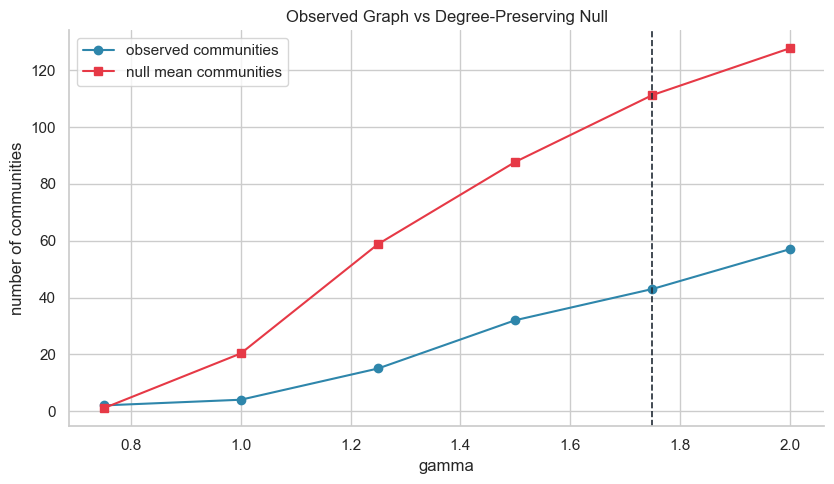

In [9]:
plot = midline.copy()
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(plot["gamma"], plot["n_communities"], marker="o", label="observed communities", color="#2E86AB")
ax.plot(plot["gamma"], plot["null_mean_n_communities"], marker="s", label="null mean communities", color="#E63946")
ax.axvline(1.75, color="#212B36", linestyle="--", linewidth=1.2)
ax.set_title("Observed Graph vs Degree-Preserving Null")
ax.set_xlabel("gamma")
ax.set_ylabel("number of communities")
ax.legend()
sns.despine()
fig.tight_layout()
fig.savefig(FIG_DIR / "observed_vs_null_community_counts.png", dpi=200, bbox_inches="tight")
plt.show()

## Final Parameter Roles

The refinement process produced a three-tier interpretation rather than a single all-purpose graph.

In [10]:
tiers = pd.DataFrame([
    {
        "tier": "Macro graph",
        "alpha": 0.001,
        "gamma": 0.75,
        "role": "broad statistically strong structure",
        "communities": 32,
        "median_nmi": 0.765,
        "null_status": "passed earlier null model",
        "use_in_project": "background / broad validation",
    },
    {
        "tier": "Validated midline graph",
        "alpha": 0.025,
        "gamma": 1.75,
        "role": "main interpretable and statistically defensible result",
        "communities": 43,
        "median_nmi": 0.758,
        "null_status": "z = 27.31",
        "use_in_project": "headline result",
    },
    {
        "tier": "Fine descriptive graph",
        "alpha": 0.025,
        "gamma": 2.00,
        "role": "fine-grained examples and artifacts",
        "communities": 57,
        "median_nmi": 0.767,
        "null_status": "failed null model, z = -3.46",
        "use_in_project": "descriptive only, not statistical claim",
    },
])
tiers

,tier,alpha,gamma,role,communities,median_nmi,null_status,use_in_project
0,Macro graph,0.001,0.75,broad statistically strong structure,32,0.765,passed earlier null model,background / broad validation
1,Validated midline graph,0.025,1.75,main interpretable and statistically defensible result,43,0.758,z = 27.31,headline result
2,Fine descriptive graph,0.025,2.00,fine-grained examples and artifacts,57,0.767,"failed null model, z = -3.46","descriptive only, not statistical claim"


## Final Decision Logic

Selected `alpha = 0.025`, `gamma = 1.75` because it gave the best validated midline:

- rich enough: 43 communities rather than only 2-4 macro groups
- not overly fragmented: largest community only 13.5% of games
- stable: median pairwise NMI = 0.758 across 20 seeds
- statistically significant: null-model z-score = 27.31
- interpretable: communities align with meaningful behavioral roles such as wargames, Golden Age canon, current heavy euros, dungeon crawl/campaign, party/social, new-hotness, and bridge/franchise clusters

The final claim:

> The `alpha = 0.025`, `gamma = 1.75` graph is the main statistically defensible midline graph. Finer settings are useful for descriptive examples, but not for statistical claims.